<a href="https://colab.research.google.com/github/WajdAlsuhaymi/IT326-DataMining-Group2/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 – Data Selection

## Project Goal
The main goal of this project is to explore the relationship between social media engagement and emotional well-being. Through data analysis, the project aims to uncover how factors such as time spent, purpose of use, and users’ demographic characteristics influence psychological outcomes. The project seeks to raise awareness about the psychological effects of social media.

## Dataset Source
Kaggle: [Social Media Usage and Emotional Well-being](https://www.kaggle.com/datasets/emirhanai/social-media-usage-and-emotional-well-being)


# Read the file

In [1]:
import pandas as pd


url = "https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv"

# قراءة الملف
df = pd.read_csv(url)

# عرض أول 5 صفوف للتأكد
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## Dataset Description and **Exploration**

In [2]:
import pandas as pd



# --------------------------------------------
# معلومات عامة عن البيانات
print("\n🔹 General Info:")
df.info()

# --------------------------------------------
# عدد السجلات (الصفوف) وعدد الأعمدة
print("\n🔹 Dataset shape (rows, columns):", df.shape)

# --------------------------------------------
# التحقق من القيم المفقودة (اختياري لكنه مفيد)
print("\n🔹 Missing values per column:")
print(df.isnull().sum())

# --------------------------------------------
# تحديد العمود الخاص بالتصنيف (Class Attribute)
# في هذه البيانات العمود هو 'Emotion' أو 'Dominant_Emotion' حسب الاسم في ملفك
class_column = 'Dominant_Emotion' # غيّري الاسم إذا مكتوب 'Dominant_Emotion'

# القيم (الفئات) الموجودة في هذا العمود
print("\n🔹 Unique emotion labels:")
print(df[class_column].unique())

# --------------------------------------------
# عدد السجلات في كل فئة (label)
print("\n🔹 Count of instances per label:")
print(df[class_column].value_counts())

# --------------------------------------------
# أنواع البيانات (Attributes types)
print("\n🔹 Data types of attributes:")
print(df.dtypes)

# --------------------------------------------


🔹 General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     924 non-null    float64
 1   Age                         924 non-null    float64
 2   Gender                      924 non-null    object 
 3   Platform                    924 non-null    object 
 4   Daily_Usage_Time (minutes)  924 non-null    float64
 5   Posts_Per_Day               924 non-null    float64
 6   Likes_Received_Per_Day      924 non-null    float64
 7   Comments_Received_Per_Day   924 non-null    float64
 8   Messages_Sent_Per_Day       924 non-null    float64
 9   Dominant_Emotion            924 non-null    object 
dtypes: float64(7), object(3)
memory usage: 72.3+ KB

🔹 Dataset shape (rows, columns): (924, 10)

🔹 Missing values per column:
User_ID                       0
Age                           0
Gen

# Normalize Gender Attribute

In [3]:
import re
import numpy as np
import pandas as pd

# --- تنظيف وضبط عمود Gender بحيث يكون فقط: Male / Female / Non-binary ---
def normalize_gender(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()

    # خرائط سريعة للقيم الشائعة
    mapping = {
        "m":"male","male":"male","man":"male","boy":"male","masculine":"male","1":"male",
        "f":"female","female":"female","woman":"female","girl":"female","feminine":"female","0":"female",
        "nb":"non-binary","nonbinary":"non-binary","non-binary":"non-binary","non binary":"non-binary",
        "2":"non-binary","other":"non-binary","others":"non-binary"
    }

    # تحويل مباشر إن وُجدت مطابقة كاملة
    s = s.map(lambda x: mapping.get(x, x))

    # محاولات regex للأخطاء الإملائية المحتملة
    s = s.str.replace(r'[^a-z\- ]', '', regex=True)          # إزالة رموز/أرقام
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()

    # تصنيف بالكلمات المفتاحية
    s = s.replace({
        r'.*\bmale\b.*': 'male',
        r'.*\bfemale\b.*': 'female',
        r'.*\bnon[- ]?binary\b.*': 'non-binary',
        r'^\b(m|man|boy)\b$': 'male',
        r'^\b(f|woman|girl)\b$': 'female',
        r'^\b(nb)\b$': 'non-binary',
    }, regex=True)

    # أي شيء ليس إحدى القيم الثلاث → NaN (نلغيّه بدل ما يطلع أرقام)
    s = s.where(s.isin(["male","female","non-binary"]), np.nan)

    # أرجعها بحالة عنوانية
    return s.map({"male":"Male","female":"Female","non-binary":"Non-binary"})

# طبّقي على داتا سِتك
df["Gender"] = normalize_gender(df["Gender"])

# --- تلخيص Gender فقط بشكل ثابت بالترتيب المطلوب ---
present = [v for v in ["Male","Female","Non-binary"] if v in df["Gender"].dropna().unique().tolist()]
gender_summary = " - ".join(present) if present else "—"
print("Gender → Nominal:", gender_summary)


Gender → Nominal: Male - Female - Non-binary


# Summarize Attributes and there types
 User_ID: Unique identifier for the user.

 Age: Age of the user.

 Gender: Gender of the user (Female, Male, Non-binary).

 Platform: Social media platform used (e.g., Instagram, Twitter, Facebook, LinkedIn, Snapchat, Whatsapp, Telegram).

 Daily_Usage_Time (minutes): Daily time spent on the platform in minutes.

 Posts_Per_Day: Number of posts made per day.

 Likes_Received_Per_Day: Number of likes received per day.

 Comments_Received_Per_Day: Number of comments received per day.

 Messages_Sent_Per_Day: Number of messages sent per day.

 Dominant_Emotion: User's dominant emotional state during the day (e.
 g., Happiness, Sadness, Anger, Anxiety, Boredom, Neutral).

In [4]:
import pandas as pd, numpy as np, re

# =============== 0) قراءة الداتا ===============
try:
    df  # إن كانت df موجودة مسبقًا
except NameError:
    df = pd.read_csv("Raw_dataset.csv")

# =============== 1) تنظيف Gender ثم تثبيته ===============
def normalize_gender(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()

    mapping = {
        "m":"male","male":"male","man":"male","boy":"male","masculine":"male","1":"male",
        "f":"female","female":"female","woman":"female","girl":"female","feminine":"female","0":"female",
        "nb":"non-binary","nonbinary":"non-binary","non-binary":"non-binary","non binary":"non-binary",
        "2":"non-binary","other":"non-binary","others":"non-binary"
    }
    s = s.map(lambda x: mapping.get(x, x))
    s = s.str.replace(r'[^a-z\- ]', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    s = s.replace({
        r'.*\bmale\b.*': 'male',
        r'.*\bfemale\b.*': 'female',
        r'.*\bnon[- ]?binary\b.*': 'non-binary',
        r'^\b(m|man|boy)\b$': 'male',
        r'^\b(f|woman|girl)\b$': 'female',
        r'^\b(nb)\b$': 'non-binary',
    }, regex=True)
    s = s.where(s.isin(["male","female","non-binary"]), np.nan)
    return s.map({"male":"Male","female":"Female","non-binary":"Non-binary"})

if "Gender" in df.columns:
    df["Gender"] = normalize_gender(df["Gender"])

# =============== 2) أدوات مساعدة للتلخيص ===============
def to_numeric_or_range(series: pd.Series):
    s = series.astype(str).str.strip()
    out = pd.Series(np.nan, index=s.index)
    for i, val in s.items():
        if re.fullmatch(r"\d+(\.\d+)?", val):
            out.at[i] = float(val)
        elif re.fullmatch(r"\d+\s*-\s*\d+", val):
            a, b = map(float, re.findall(r"\d+", val))
            out.at[i] = (a + b) / 2
    return out

def summarize_one(col: str, max_list=15):
    s = df[col].dropna()

    # --- الشرط الخاص بـ Gender: دائماً Nominal بالقيم الثلاث ---
    if col == "Gender":
        return "Nominal", "Male - Female - Non-binary"

    # محاولة اعتباره رقميًا مباشرة
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        mn, mx = num.min(), num.max()
        fmt = lambda v: f"{int(v)}" if float(v).is_integer() else f"{v:.4g}"
        return "Numeric", f"{fmt(mn)} - {fmt(mx)}"

    # محاولة تحويل نطاقات نصية لأرقام
    num2 = to_numeric_or_range(s)
    if num2.notna().any():
        mn, mx = num2.min(), num2.max()
        fmt = lambda v: f"{int(v)}" if float(v).is_integer() else f"{v:.4g}"
        return "Numeric", f"{fmt(mn)} - {fmt(mx)}"

    # اسمي (Nominal)
    uniq = sorted(s.astype(str).str.strip().unique(), key=lambda x: x.lower())
    vals = " - ".join(uniq[:max_list]) + (f" - ... (+{len(uniq)-max_list} more)" if len(uniq) > max_list else "")
    return "Nominal", (vals if vals else "—")

# =============== 3) بناء جدول الملخص ===============
order = [
    "User_ID","Age","Gender","Platform",
    "Daily_Usage_Time (minutes)","Posts_Per_Day","Likes_Received_Per_Day",
    "Comments_Received_Per_Day","Messages_Sent_Per_Day","Dominant_Emotion"
]

rows = []
for col in order:
    if col not in df.columns:
        rows.append({"Attribute": f"{col} (NOT FOUND)", "Type": "-", "Range / Possible Values": "-"})
        continue
    t, rng = summarize_one(col, max_list=15)
    rows.append({"Attribute": col, "Type": t, "Range / Possible Values": rng})

summary = pd.DataFrame(rows)
summary["__o__"] = summary["Type"].map({"Numeric": 0, "Nominal": 1}).fillna(2)
summary = summary.sort_values(["__o__", "Attribute"]).drop(columns="__o__").reset_index(drop=True)

# عرض النتيجة
summary

,Attribute,Type,Range / Possible Values
0,Age,Numeric,21 - 35
1,Comments_Received_Per_Day,Numeric,2 - 40
2,Daily_Usage_Time (minutes),Numeric,40 - 200
3,Likes_Received_Per_Day,Numeric,5 - 110
4,Messages_Sent_Per_Day,Numeric,8 - 50
5,Posts_Per_Day,Numeric,1 - 8
6,User_ID,Numeric,1 - 1000
7,Dominant_Emotion,Nominal,Anger - Anxiety - Boredom - Happiness - Neutra...
8,Gender,Nominal,Male - Female - Non-binary
9,Platform,Nominal,Facebook - Instagram - LinkedIn - Snapchat - T...


# Phase 2 – Data Summarization and Preprocessing

This phase focuses on analyzing and preparing the dataset before applying data mining techniques.
It includes summarizing data, visualizing relationships, handling missing values, and applying preprocessing techniques such as encoding, normalization, and outlier removal.

### **Part** 1 : Data Summarization

In [ ]:

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading the Dataset
url='https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
df = pd.read_csv(url)
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
# General Information and Missing Values
print("Dataset Shape:", df.shape)
df.info()

# Missing values summary
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


Dataset Shape: (924, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     924 non-null    float64
 1   Age                         924 non-null    float64
 2   Gender                      924 non-null    object 
 3   Platform                    924 non-null    object 
 4   Daily_Usage_Time (minutes)  924 non-null    float64
 5   Posts_Per_Day               924 non-null    float64
 6   Likes_Received_Per_Day      924 non-null    float64
 7   Comments_Received_Per_Day   924 non-null    float64
 8   Messages_Sent_Per_Day       924 non-null    float64
 9   Dominant_Emotion            924 non-null    object 
dtypes: float64(7), object(3)
memory usage: 72.3+ KB


,0


In [ ]:
# Statistical Summary
df.describe().T  # Includes five-number summary for numeric columns


,count,mean,std,min,25%,50%,75%,max
User_ID,924.0,498.937229,291.713692,1.0,231.75,500.5,731.25,1000.0
Age,924.0,27.500000,3.941473,21.0,24.00,27.0,30.00,35.0
Daily_Usage_Time (minutes),924.0,96.309524,39.228274,40.0,65.00,85.0,120.00,200.0
Posts_Per_Day,924.0,3.349567,1.940080,1.0,2.00,3.0,5.00,8.0
Likes_Received_Per_Day,924.0,40.246753,26.799196,5.0,19.50,33.0,55.00,110.0
Comments_Received_Per_Day,924.0,15.726190,8.933589,2.0,8.00,14.0,22.00,40.0
Messages_Sent_Per_Day,924.0,22.595238,8.634295,8.0,17.00,22.0,28.00,50.0


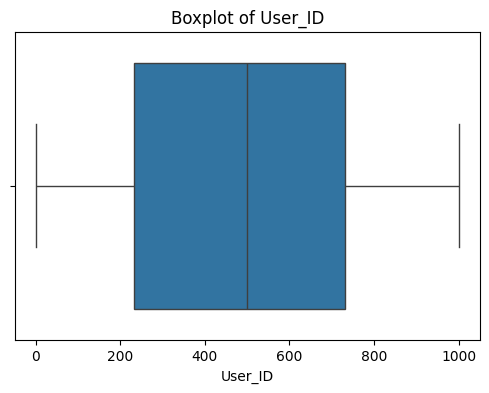

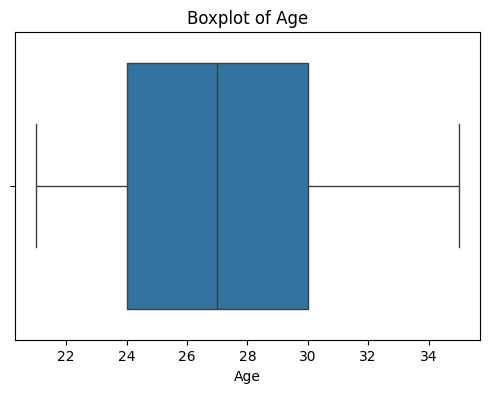

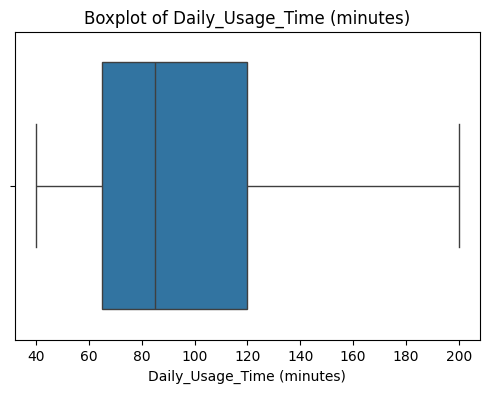

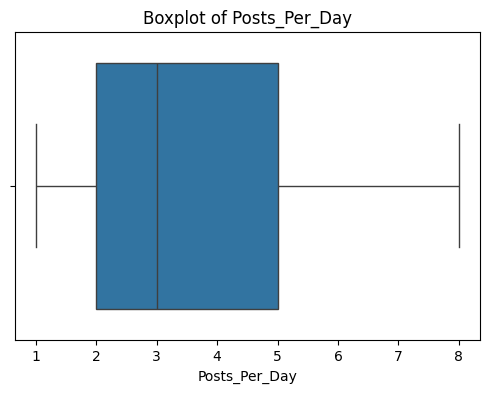

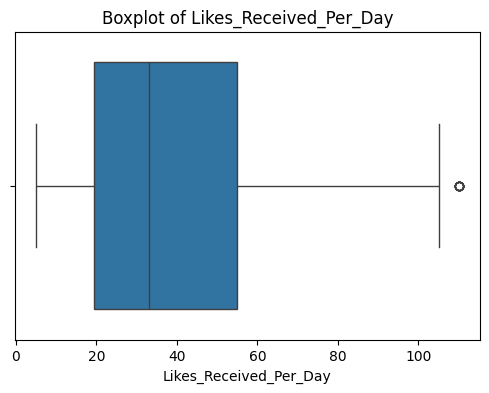

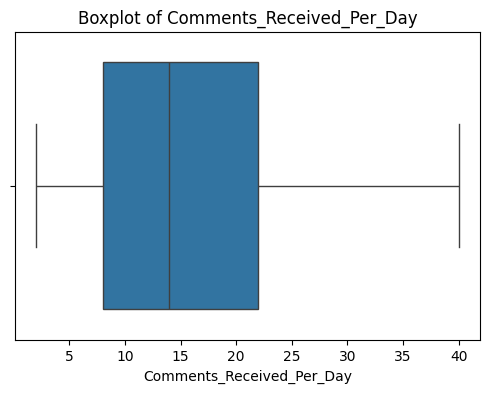

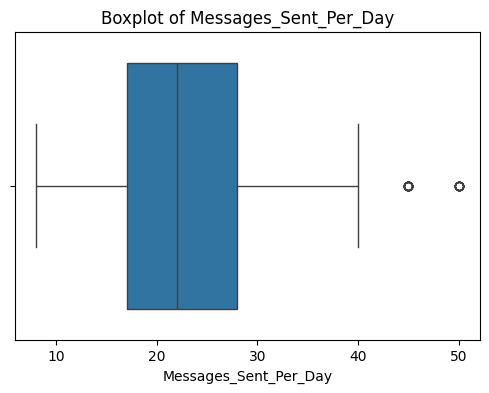

In [ ]:
# Boxplots and Outlier Detection
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


The boxplots were created to quickly visualize the distribution of each numeric variable and detect potential outliers. They illustrate the median, spread, and skewness of each feature, along with any extreme values that fall outside the normal range. From these graphs, you can conclude which variables contain outliers, which ones are skewed, and whether certain features may require cleaning, scaling, or transformation before further analysis or modeling.

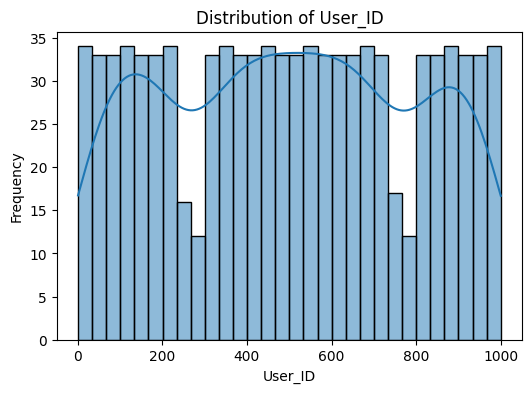

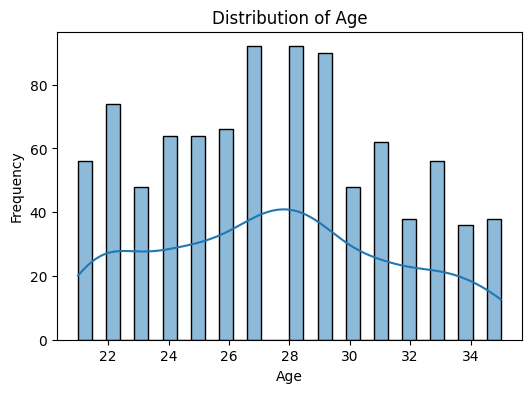

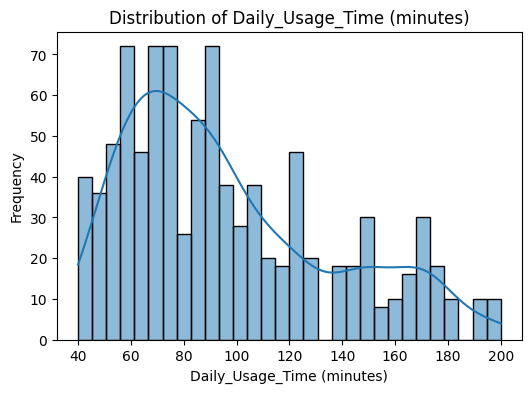

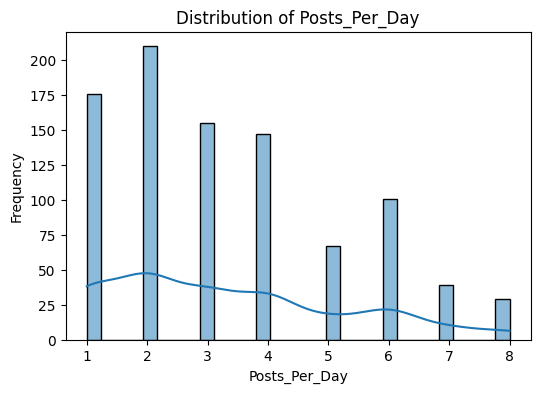

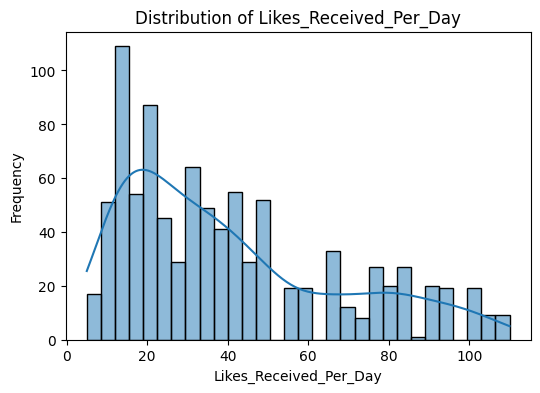

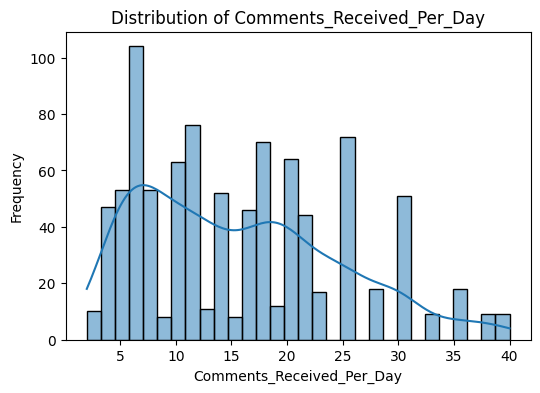

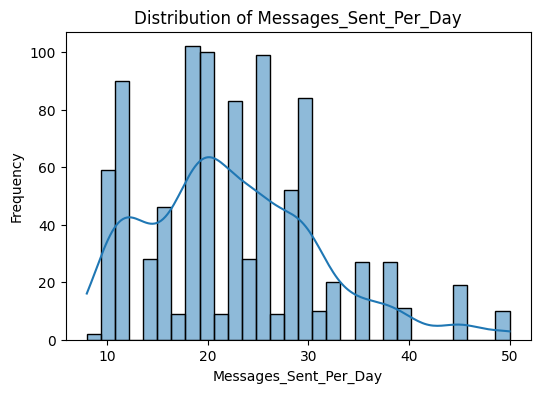

In [ ]:
# Histograms for Numeric Distributions
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


The histograms were created to examine the underlying distribution of each numeric variable, helping determine whether the data is normal, skewed, uniform, or multimodal. Each graph illustrates the frequency of values within bins, along with a KDE curve that highlights the overall shape and smoothness of the distribution. From these histograms, you can conclude how spread out each variable is, whether the data is concentrated in specific ranges, if transformations might be needed (e.g., for skewed data), and whether any unusual patterns or multiple peaks suggest different subgroups or behaviors in the dataset.

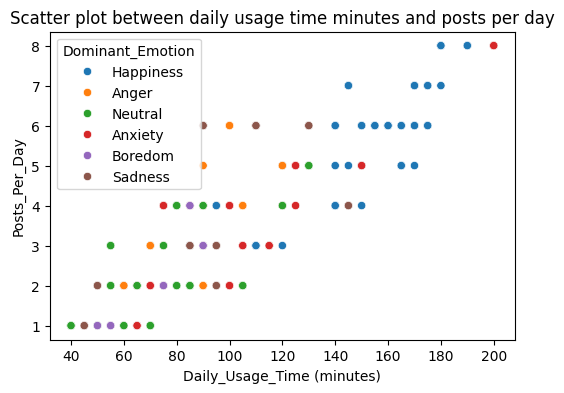

In [ ]:
# Scatter Plot (Pairwise Comparison)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Daily_Usage_Time (minutes)', y='Posts_Per_Day', hue='Dominant_Emotion')
plt.title('Scatter plot between daily usage time minutes and posts per day')
plt.show()


The scatter plot was created to explore the relationship between daily usage time and the number of posts per day, with color-coding added to observe how dominant emotions vary across this relationship. It illustrates how the two variables interact—whether they show a positive or negative trend, clusters, or randomness—while also showing whether certain emotional states are associated with higher or lower usage or posting patterns. From this graph, you can conclude whether increased usage time corresponds to more frequent posting, identify any visible patterns or groupings among users with different dominant emotions, and detect possible behavioral trends or outliers that may warrant deeper analysis.

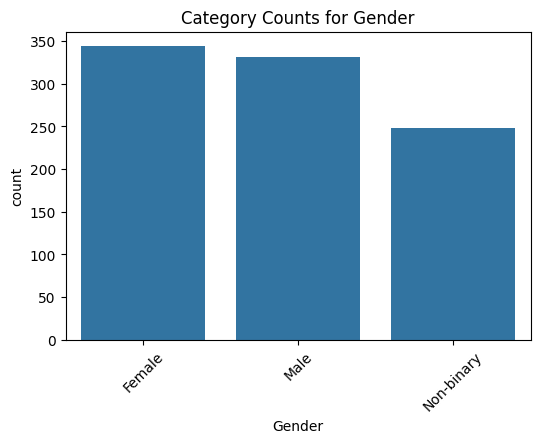

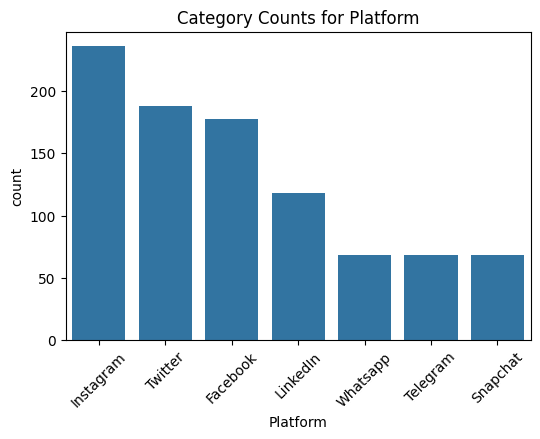

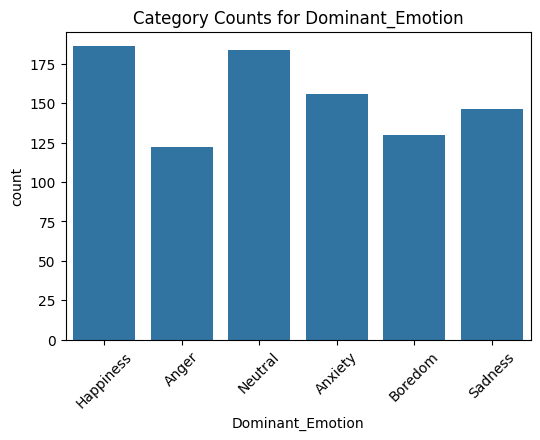

In [ ]:
# Bar Plots for Categorical Features
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Category Counts for {col}')
    plt.xticks(rotation=45)
    plt.show()


The bar plots were created to visualize the frequency distribution of each categorical feature, allowing you to quickly see how often each category appears in the dataset. They illustrate the counts of all unique categories within a variable, making it easy to spot dominant groups, rare categories, and overall balance or imbalance in the data. From these graphs, you can conclude which categories are most common, whether the feature is skewed toward certain groups, and whether rare categories may need merging, encoding adjustments, or special handling during analysis or modeling.

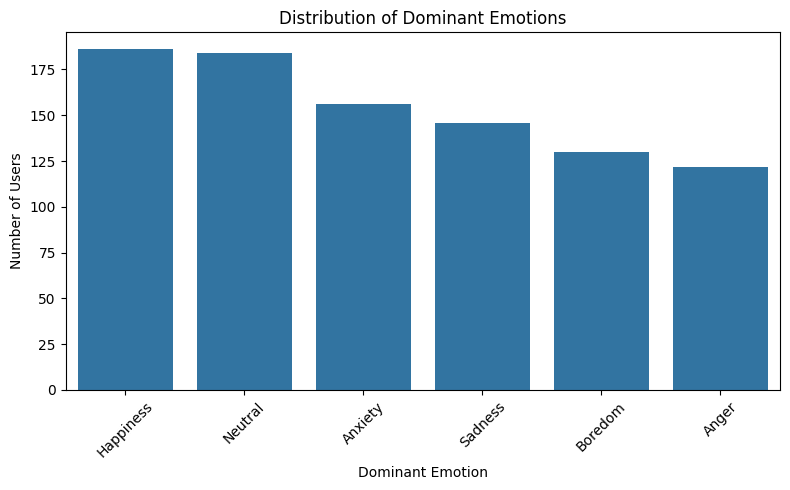

In [ ]:
# Class Label Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Dominant_Emotion', order=df['Dominant_Emotion'].value_counts().index)
plt.title('Distribution of Dominant Emotions')
plt.xlabel('Dominant Emotion')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This bar plot was created to examine the distribution of the target variable, Dominant Emotion, ensuring a clear understanding of how balanced or imbalanced the emotion classes are. It illustrates the frequency of each emotion category in descending order, making it easy to see which emotions are most common and which are underrepresented. From this graph, you can conclude whether the dataset suffers from class imbalance—important for model training—and identify which emotions dominate the user base, which may also reveal general emotional trends within the population.

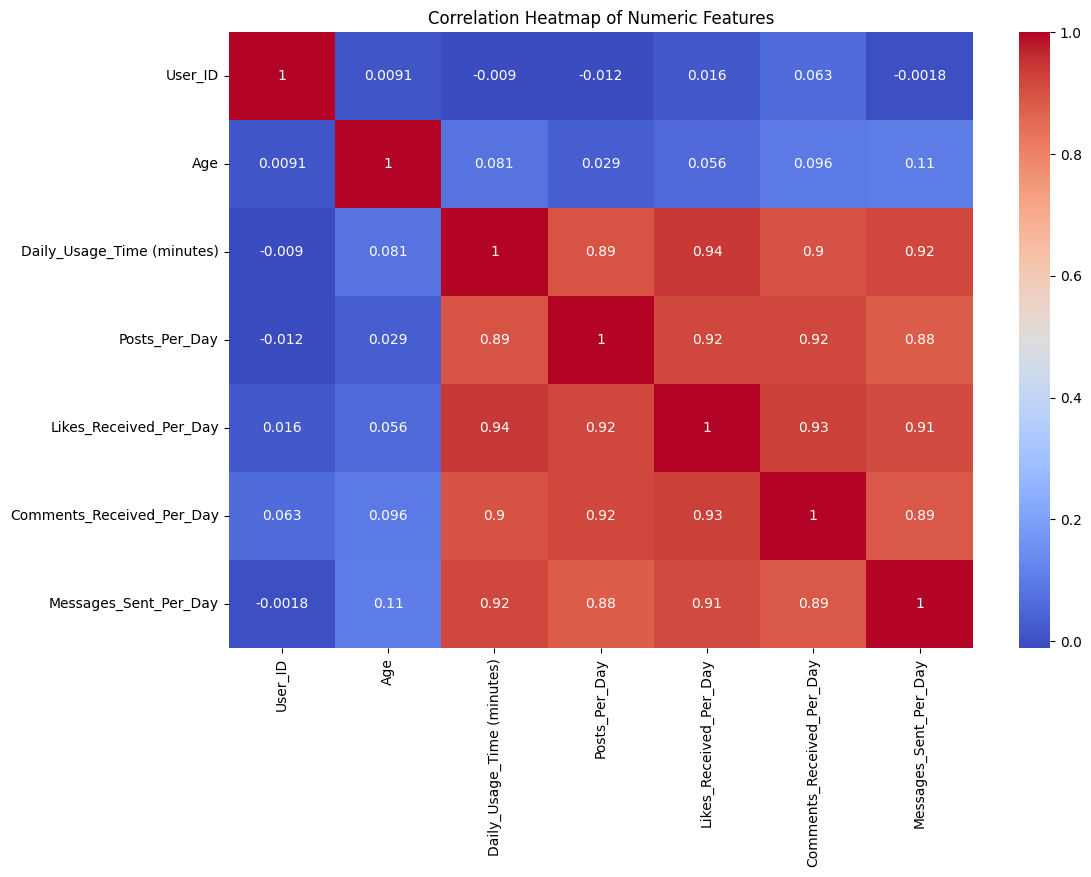

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


The correlation heatmap was created to understand how the numeric variables in the dataset relate to each other and to identify any strong positive or negative correlations. It illustrates the pairwise correlation coefficients between all numeric features, using color intensity and annotated values to highlight the strength and direction of each relationship. From this graph, you can conclude which variables move together, which ones are inversely related, and whether any features are highly correlated enough to indicate redundancy or multicollinearity—important for feature selection, interpretation, and improving model performance.

### **Part 2**: Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Handling Missing Values

We used mean to fill missing numeric values and mode for categorical columns (Gender, Platform, Dominant_Emotion).
This was done to avoid losing rows and keep the dataset complete for analysis









In [ ]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

print("Shape after dropping empty rows:", df.shape)

# Create a new DataFrame for preprocessing
df_processed = df.copy()

print("A new copy 'df_processed' is created for preprocessing.")
df_processed.head()


Shape after dropping empty rows: (924, 10)
A new copy 'df_processed' is created for preprocessing.


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# Drop any completely empty rows
df = df.dropna(how='all')

# Create a new dataset for preprocessing
df_processed = df.copy()

# Define numeric columns
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# Convert numeric columns to proper numeric dtype
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing numeric values with mean for each column
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("✔ Numeric columns cleaned and missing values filled successfully!")
df_processed.head()


✔ Numeric columns cleaned and missing values filled successfully!


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## 1) Loading the Raw Dataset
We loaded the raw dataset and removed any completely empty rows to ensure data consistency before preprocessing.

In [ ]:
import pandas as pd

# تحميل الداتا من الراو مرّة واحدة
df = pd.read_csv("https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv")

# حذف الصفوف الفارغة بالكامل (احتياطي)
df = df.dropna(how='all')

# إنشاء نسخة للبروسسينق
df_processed = df.copy()

print("Shape:", df_processed.shape)
df_processed.head()


Shape: (924, 10)


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1.0,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2.0,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3.0,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4.0,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5.0,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


## 2) Cleaning Numeric Attributes
We converted all numeric attributes to proper numerical format and filled missing values using the mean of each column.
This ensures that the dataset contains no null values and remains suitable for machine learning algorithms.

In [ ]:
# تعريف الأعمدة الرقمية
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# تحويل للأرقام (احتياط)
df_processed[numeric_cols] = df_processed[numeric_cols].apply(pd.to_numeric, errors='coerce')

# تعويض القيم الناقصة بالمتوسط لكل عمود
for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

print("✔ Numeric columns cleaned and missing values filled.")
df_processed[numeric_cols].head()


✔ Numeric columns cleaned and missing values filled.


,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
0,25.0,120.0,3.0,45.0,10.0,12.0
1,30.0,90.0,5.0,20.0,25.0,30.0
2,22.0,60.0,2.0,15.0,5.0,20.0
3,28.0,200.0,8.0,100.0,30.0,50.0
4,33.0,45.0,1.0,5.0,2.0,10.0


## 3) Discretization (Age Binning) – For Analysis Only
We applied binning on the Age attribute by grouping users into defined age ranges.
This step helps analyze behavioral differences between age groups.
(This transformation was used only for reporting and was not stored as a new column.)

In [ ]:
# Binning على العمر الحقيقي للتحليل فقط (لا نحفظه ككولوم)
bins = [20, 25, 30, 35]
labels = ['21–25', '26–30', '31–35']

age_binned_temp = pd.cut(df_processed['Age'], bins=bins, labels=labels, include_lowest=True)

print("✔ Binning based on REAL Age (for analysis only):")
print(age_binned_temp.value_counts())


✔ Binning based on REAL Age (for analysis only):
Age
26–30    388
21–25    306
31–35    230
Name: count, dtype: int64


## 4) Encoding Categorical Data
We applied Label Encoding on the categorical attributes Gender and Platform.
This converts textual categories into numerical values that machine learning algorithms can process.
The target class (Dominant_Emotion) was excluded from encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_cols = ["Gender", "Platform"]

for col in label_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("✔ Label encoding applied on Gender and Platform.")
df_processed[label_cols].head()


✔ Label encoding applied on Gender and Platform.


,Gender,Platform
0,0,1
1,1,5
2,2,0
3,0,1
4,1,2


## 5) Normalization
We applied Min–Max Normalization to scale all numeric attributes between 0 and 1.
This ensures that features with larger numeric ranges (such as usage time) do not dominate the learning process.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

numeric_to_scale = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day",
    "Gender"  # الآن صار رقمي ونقدر نطبّعه
]

scaler = MinMaxScaler()
df_processed[numeric_to_scale] = scaler.fit_transform(df_processed[numeric_to_scale])

print("✔ Normalization applied on numeric columns (including Age & Gender).")
df_processed[numeric_to_scale].head()


✔ Normalization applied on numeric columns (including Age & Gender).


,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Gender
0,0.285714,0.50000,0.285714,0.380952,0.210526,0.095238,0.0
1,0.642857,0.31250,0.571429,0.142857,0.605263,0.523810,0.5
2,0.071429,0.12500,0.142857,0.095238,0.078947,0.285714,1.0
3,0.500000,1.00000,1.000000,0.904762,0.736842,1.000000,0.0
4,0.857143,0.03125,0.000000,0.000000,0.000000,0.047619,0.5


### 6) Age Normalization
After examining the age distribution, we normalized the Age column using Min–Max scaling to keep it consistent with the rest of the normalized numerical features.

## 7) Removing User_ID & Saving
We removed the User_ID attribute because it serves only as an identifier and has no analytical value.
Keeping it would introduce unnecessary noise and could negatively affect model performance.

In [ ]:
# حذف User_ID إذا موجود
if "User_ID" in df_processed.columns:
    df_processed = df_processed.drop(columns=["User_ID"])
    print("✔ 'User_ID' column removed from df_processed.")
else:
    print("ℹ 'User_ID' not found in df_processed.")

print("New DataFrame shape:", df_processed.shape)

# حفظ الملف النهائي في ملف واحد فقط
df_processed.to_csv("Preprocessed_dataset.csv", index=False)
print("✔ Preprocessed_dataset.csv saved successfully!")


✔ 'User_ID' column removed from df_processed.
New DataFrame shape: (924, 9)
✔ Preprocessed_dataset.csv saved successfully!


# Final Data Preprocessing Summary (Phase 2)Technique: Data Export


1. Removed Empty Rows

All completely empty rows were deleted to ensure the dataset contained only valid and usable records.

2. Cleaned and Standardized Numeric Attributes

Numeric columns (Age, Daily Usage Time, Posts Per Day, Likes, Comments, Messages) were converted to proper numeric type using to_numeric() with error handling.
Missing values were filled using mean imputation to maintain data consistency.

3. Age Analysis Using Discretization (Binning – Analysis Only)

Age was grouped into defined categories (21–25, 26–30, 31–35) to study behavioral differences among user groups.
This transformation was temporary and used only for analysis; it was not stored in the final dataset.

4. Encoded Categorical Attributes

Label Encoding was applied to the categorical features Gender and Platform to convert them into numeric form suitable for machine learning algorithms.
The target attribute (Dominant_Emotion) remained unchanged.

5. Normalized Numeric Features

Min–Max Normalization was applied to all continuous numeric attributes—including Age and Gender—to scale them between 0 and 1 and ensure equal weighting in modeling.

6. Removed Irrelevant Attribute

The User_ID column was removed because it only serves as an identifier and has no analytical or predictive value.

7. Saved the Final Preprocessed File

 After completing all preprocessing steps, the cleaned dataset was saved as Preprocessed_dataset.csv, making it ready for use in Phase 3 (data analysis & modeling).

# Summarize Attributes and there types after pre-processing

In [ ]:
# 📊 Enhanced Column Summary Report (for df_processed)
import pandas as pd
import numpy as np

print("🔍 Dataset Columns Summary (df_processed)\n")

for col in df_processed.columns:
    dtype = df_processed[col].dtype

    print(f"📌 Column Name: {col}")
    print(f"   ▪️ Data Type: {dtype}")

    # عدد القيم الفارغة
    missing = df_processed[col].isna().sum()
    print(f"   ▪️ Missing Values: {missing}")

    # إذا العمود رقمي
    if pd.api.types.is_numeric_dtype(df_processed[col]):
        col_min = df_processed[col].min()
        col_max = df_processed[col].max()
        print(f"   ▪️ Range: {col_min} → {col_max}")
    else:
        unique_vals = df_processed[col].unique()
        unique_count = len(unique_vals)
        if unique_count <= 10:
            print(f"   ▪️ Unique Values: {list(unique_vals)}")
        else:
            print(f"   ▪️ Unique Values Count: {unique_count}")

    print("-" * 60)


🔍 Dataset Columns Summary (df_processed)

📌 Column Name: Age
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Gender
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Platform
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 6
------------------------------------------------------------
📌 Column Name: Daily_Usage_Time (minutes)
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Posts_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Likes_Received_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
-----------------------------------------------------

# **Phase 3**

#Classification

1. Load The Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Preprocessed_dataset.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (924, 9)


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,0.642857,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,0.071429,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,0.500000,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,0.857143,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


2. Prepocessing

In [ ]:
# Target column = last column
target_col = df.columns[-1]
# Drop missing target rows
df = df.dropna(subset=[target_col]).reset_index(drop=True)
X = df.drop(columns=[target_col])
y = df[target_col]
# Encode target labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# One-hot encode categorical features
X = pd.get_dummies(X)
print("Features:", X.shape)
print("Target:", y_encoded.shape)


Features: (924, 16)
Target: (924,)


3. Setting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
splits = {
"60_40": 0.40,
"70_30": 0.30,
"80_20": 0.20
}
criteria = ["gini", "entropy"]

4. Experiment Loop


Split: 60_40 | Criterion: gini

Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

       Anger       0.96      0.98      0.97        49
     Anxiety       0.97      0.94      0.95        62
     Boredom       0.96      0.96      0.96        52
   Happiness       0.99      0.97      0.98        75
     Neutral       0.99      0.99      0.99        74
     Sadness       0.92      0.95      0.93        58

    accuracy                           0.96       370
   macro avg       0.96      0.96      0.96       370
weighted avg       0.97      0.96      0.96       370



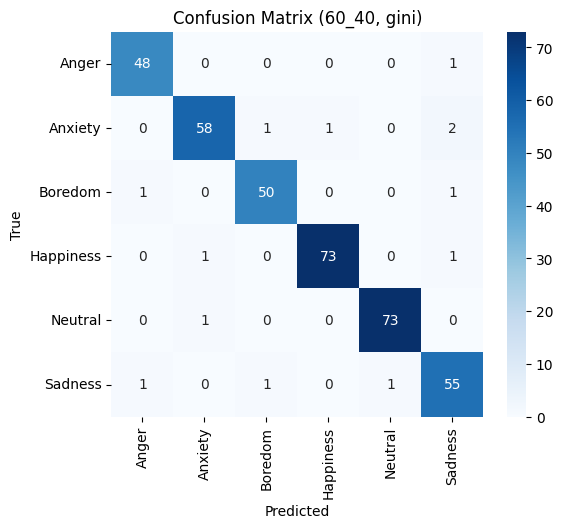

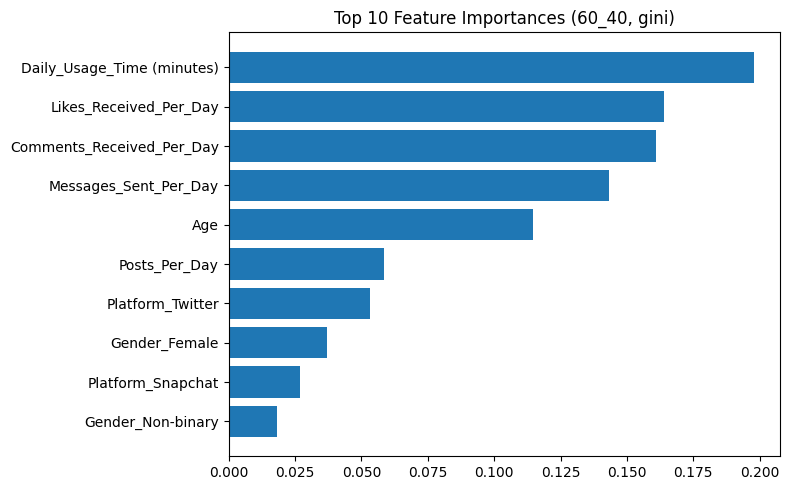

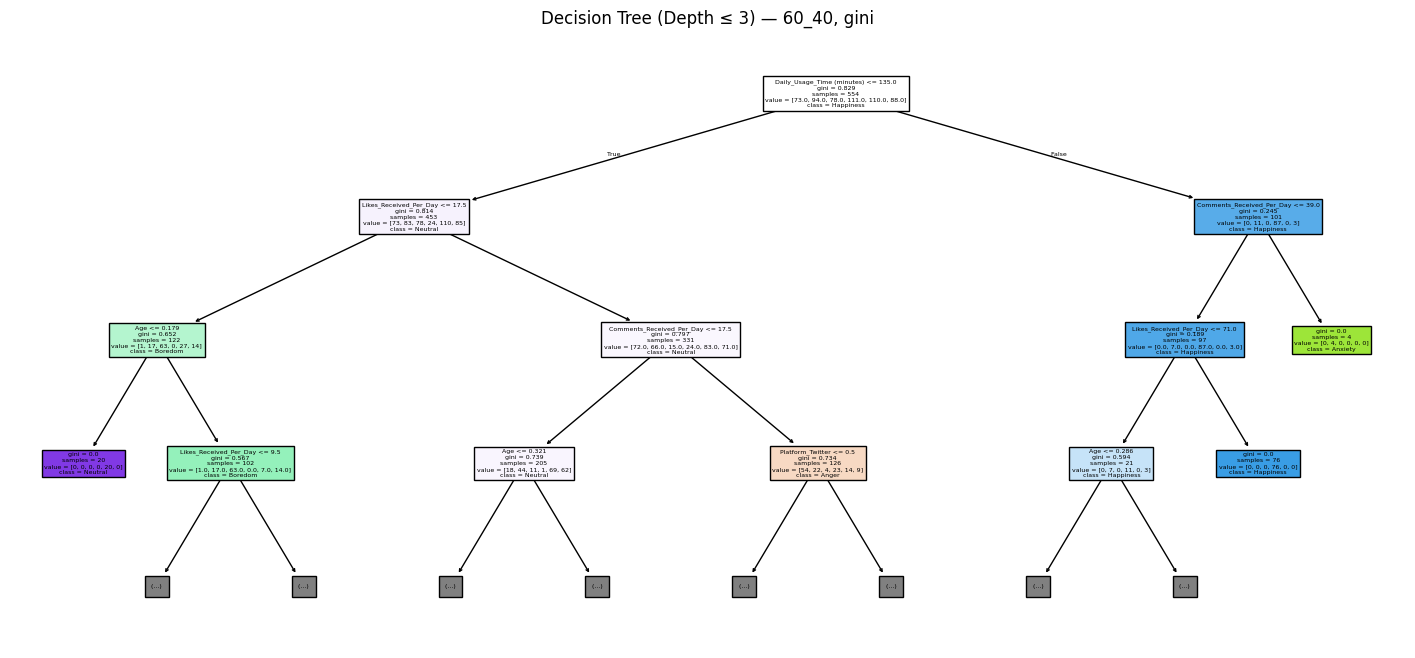


Split: 60_40 | Criterion: entropy

Accuracy: 0.9568

Classification Report:
              precision    recall  f1-score   support

       Anger       0.91      0.98      0.94        49
     Anxiety       0.97      0.95      0.96        62
     Boredom       0.91      0.96      0.93        52
   Happiness       0.99      0.97      0.98        75
     Neutral       0.99      0.95      0.97        74
     Sadness       0.96      0.93      0.95        58

    accuracy                           0.96       370
   macro avg       0.95      0.96      0.95       370
weighted avg       0.96      0.96      0.96       370



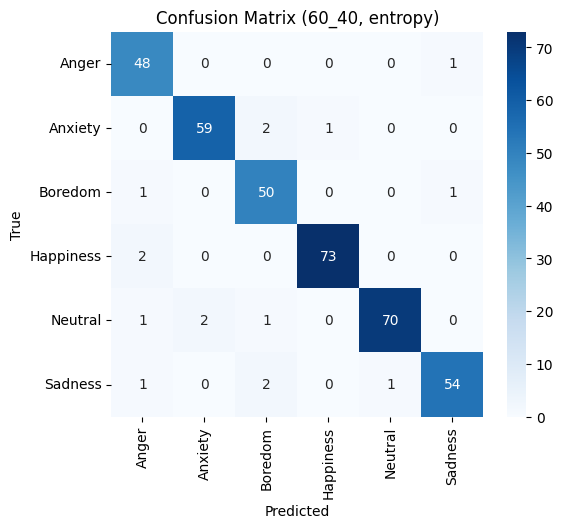

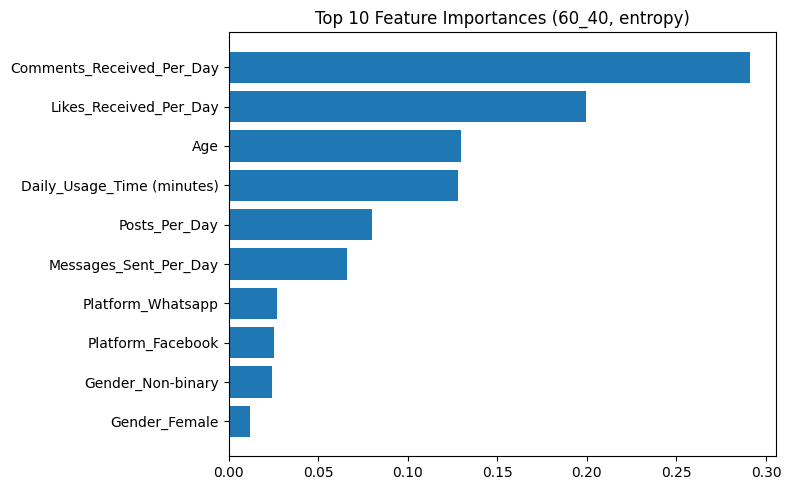

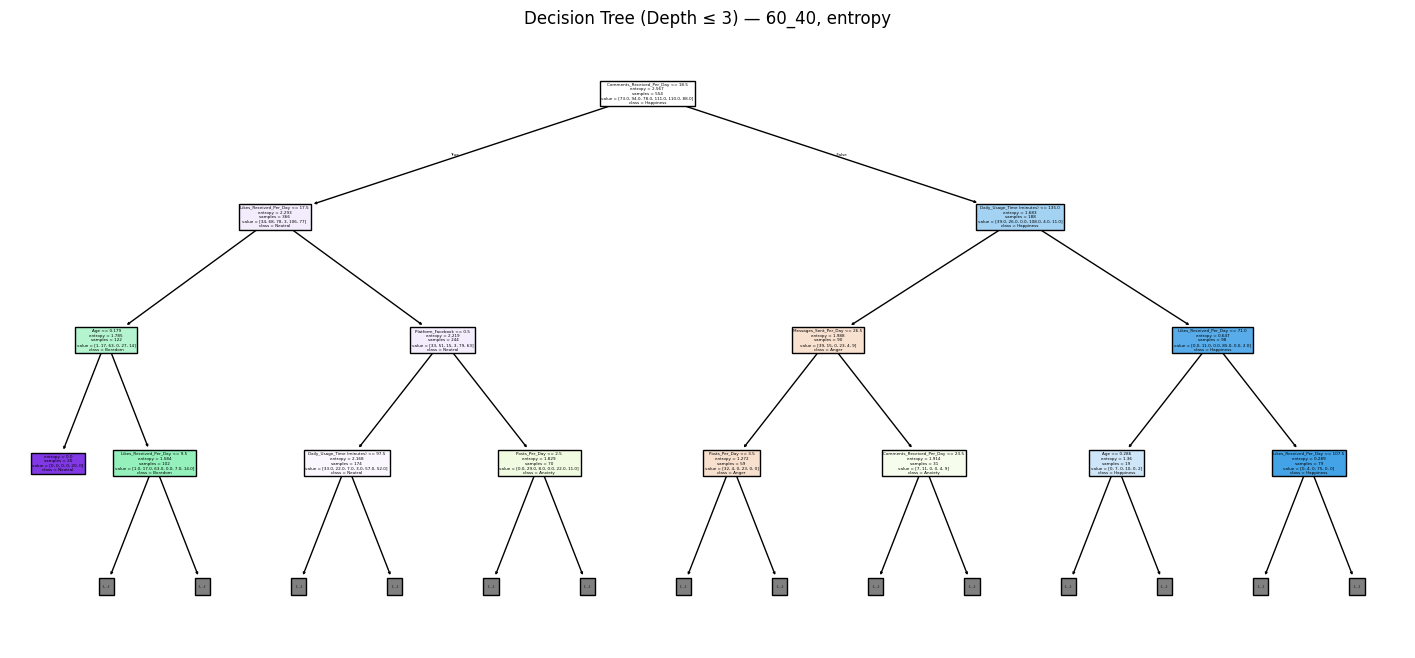


Split: 70_30 | Criterion: gini

Accuracy: 0.9532

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      0.97      0.99        37
     Anxiety       0.96      0.94      0.95        47
     Boredom       0.90      0.95      0.93        39
   Happiness       0.96      0.96      0.96        56
     Neutral       0.96      0.98      0.97        55
     Sadness       0.93      0.91      0.92        44

    accuracy                           0.95       278
   macro avg       0.95      0.95      0.95       278
weighted avg       0.95      0.95      0.95       278



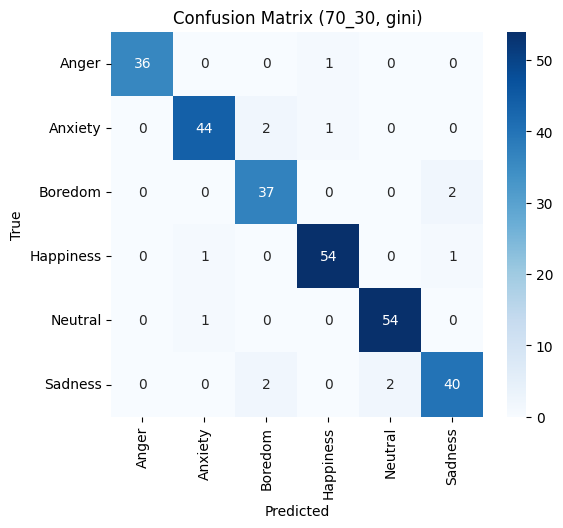

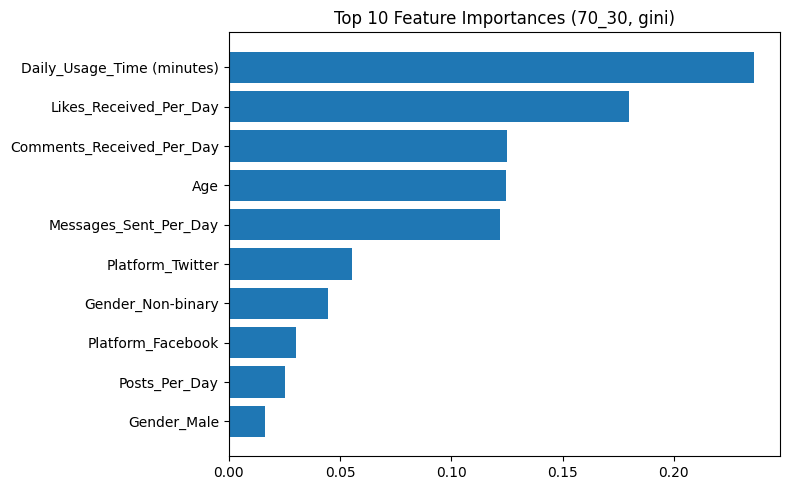

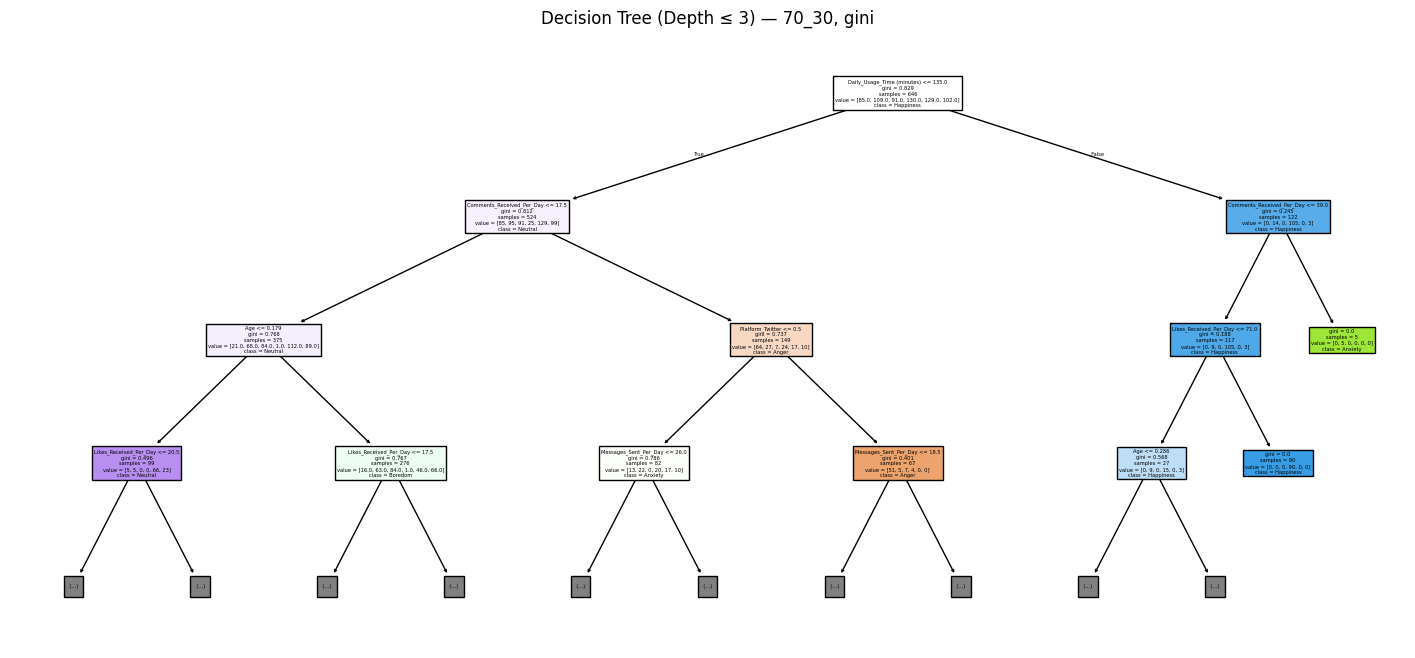


Split: 70_30 | Criterion: entropy

Accuracy: 0.9568

Classification Report:
              precision    recall  f1-score   support

       Anger       0.97      0.97      0.97        37
     Anxiety       0.98      0.91      0.95        47
     Boredom       0.91      1.00      0.95        39
   Happiness       0.98      0.95      0.96        56
     Neutral       0.95      1.00      0.97        55
     Sadness       0.95      0.91      0.93        44

    accuracy                           0.96       278
   macro avg       0.96      0.96      0.96       278
weighted avg       0.96      0.96      0.96       278



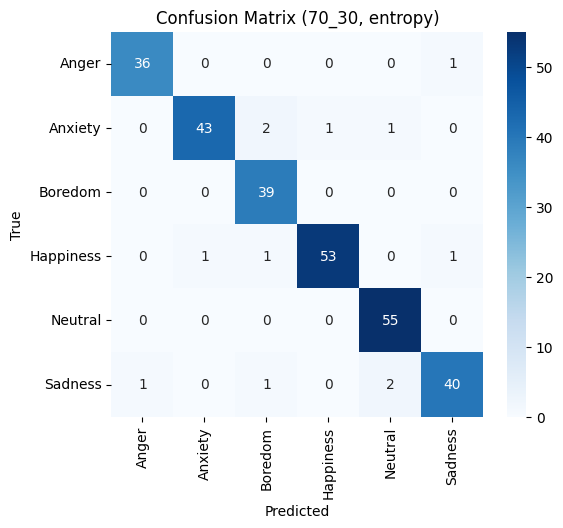

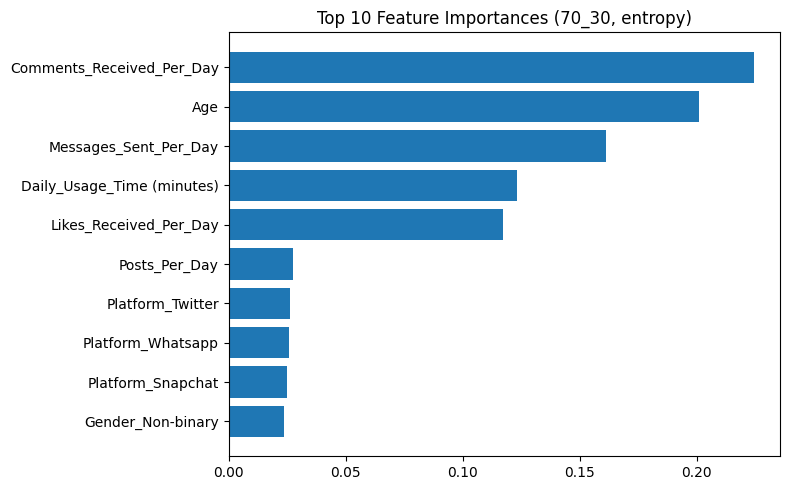

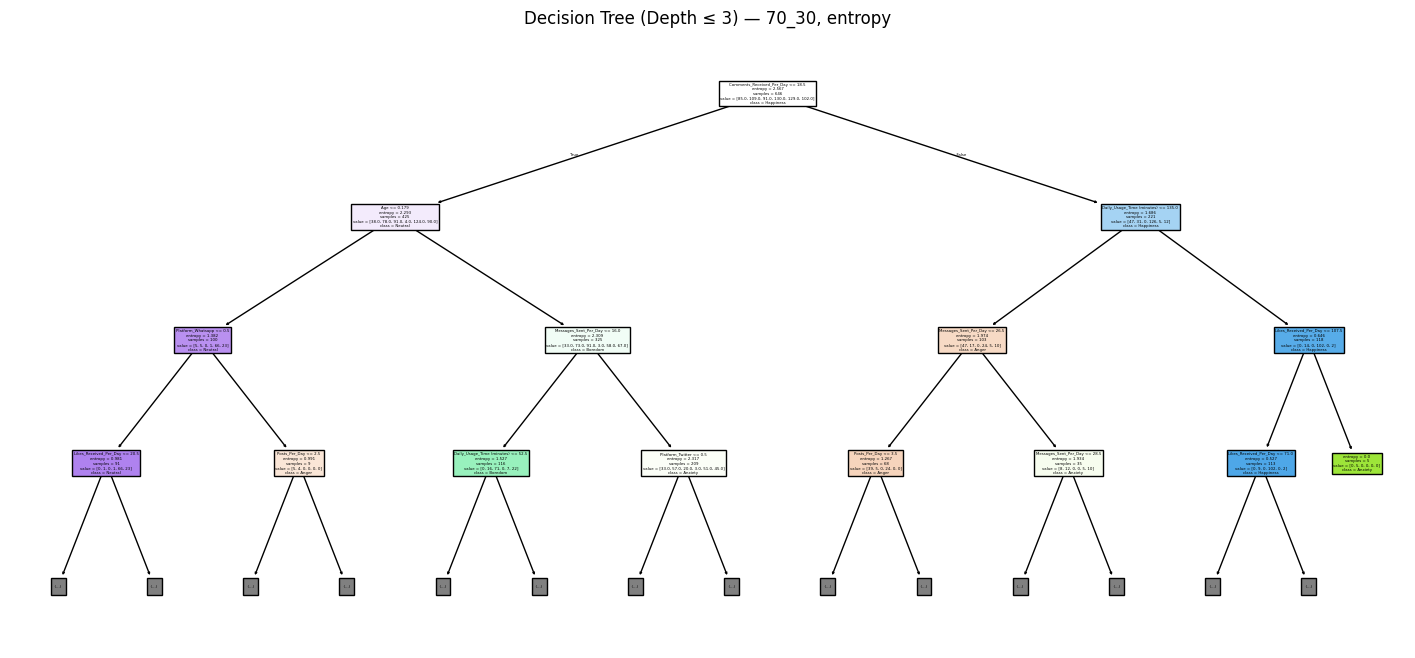


Split: 80_20 | Criterion: gini

Accuracy: 0.9730

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      0.96      0.98        25
     Anxiety       0.97      0.90      0.93        31
     Boredom       0.90      1.00      0.95        26
   Happiness       0.97      1.00      0.99        37
     Neutral       1.00      0.97      0.99        37
     Sadness       1.00      1.00      1.00        29

    accuracy                           0.97       185
   macro avg       0.97      0.97      0.97       185
weighted avg       0.97      0.97      0.97       185



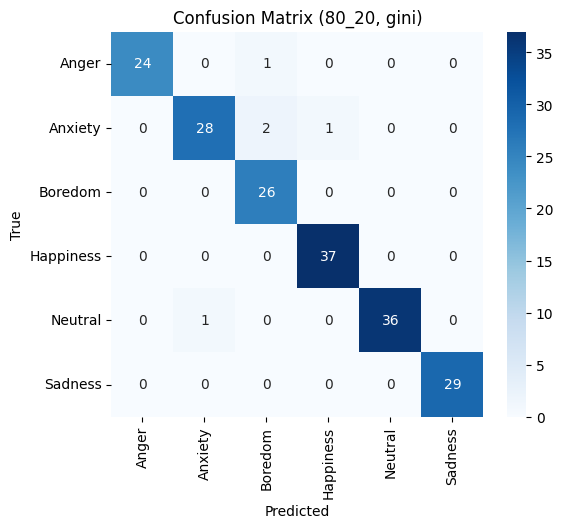

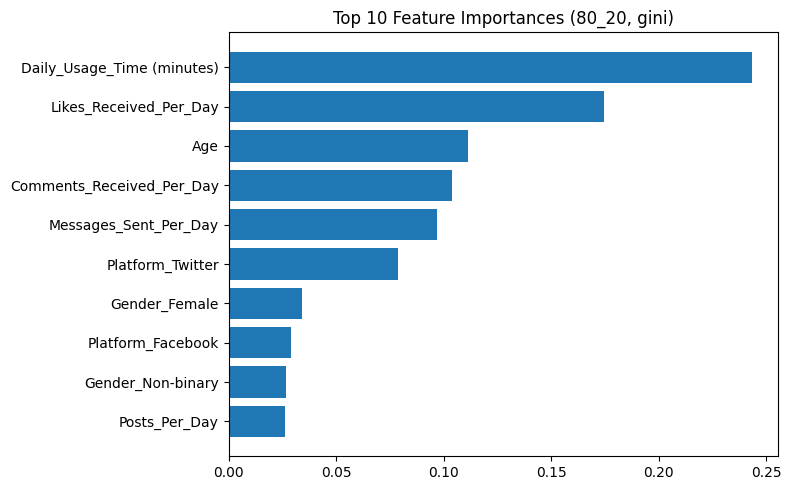

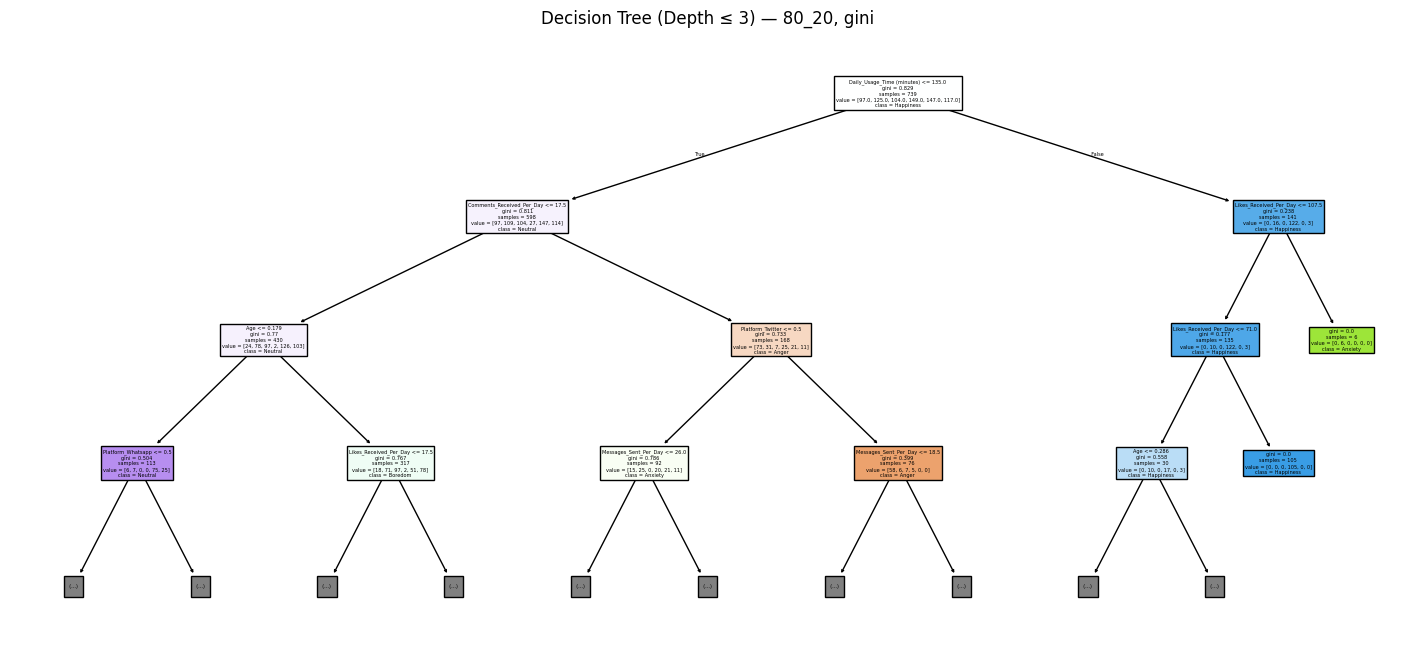


Split: 80_20 | Criterion: entropy

Accuracy: 0.9622

Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      0.92      0.96        25
     Anxiety       0.94      0.97      0.95        31
     Boredom       0.96      1.00      0.98        26
   Happiness       1.00      0.95      0.97        37
     Neutral       0.97      0.97      0.97        37
     Sadness       0.90      0.97      0.93        29

    accuracy                           0.96       185
   macro avg       0.96      0.96      0.96       185
weighted avg       0.96      0.96      0.96       185



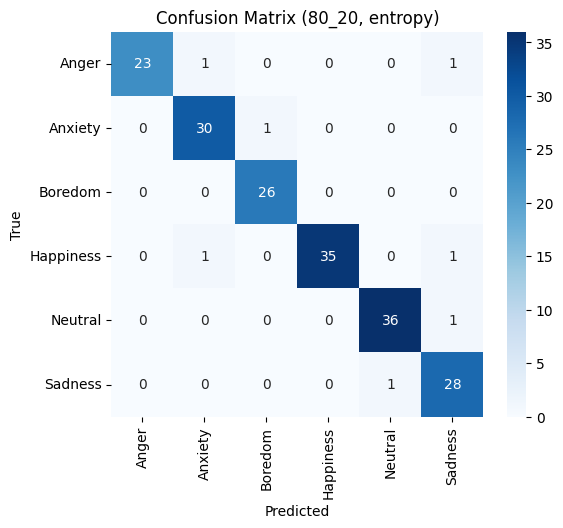

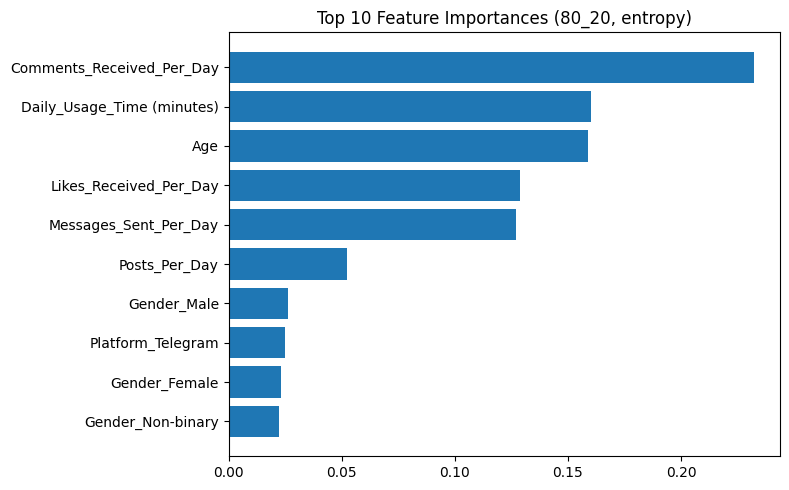

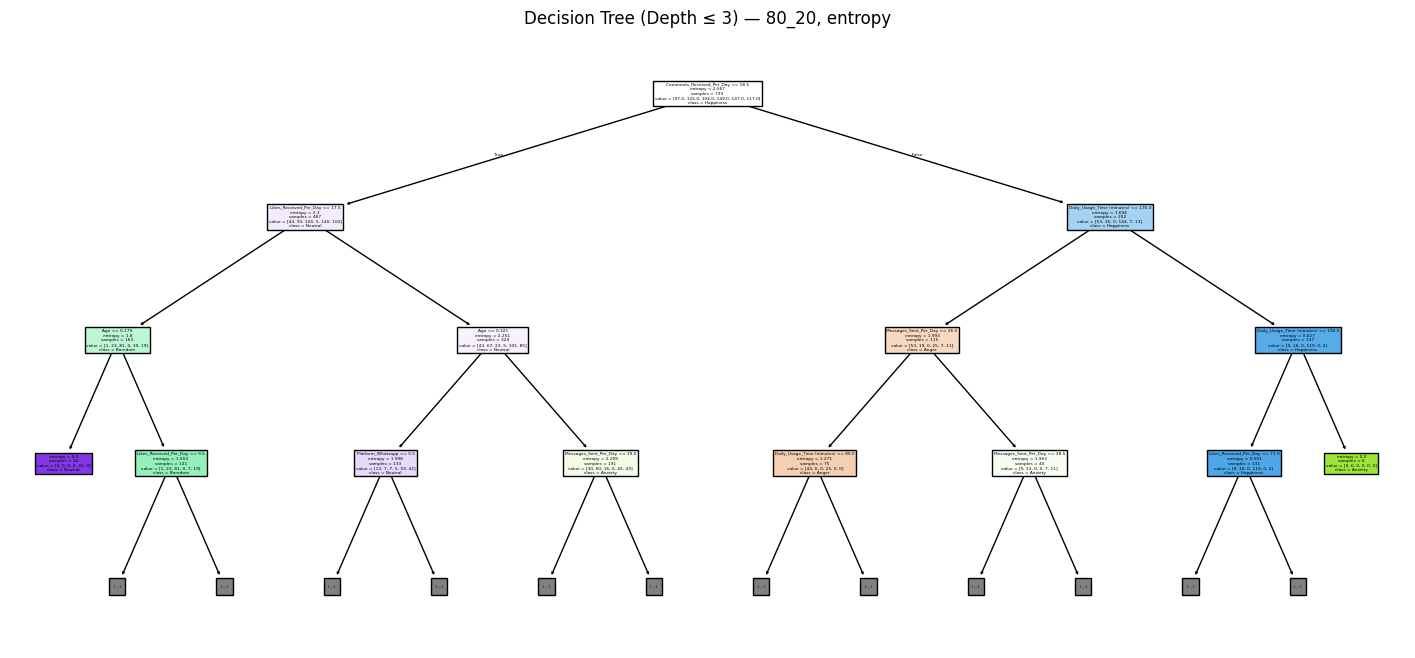

In [ ]:
for split_name, test_size in splits.items():
    for crit in criteria:
        print("\n=====================================")
        print(f"Split: {split_name} | Criterion: {crit}")
        print("=====================================\n")
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
        )
        # Model
        model = DecisionTreeClassifier(criterion=crit, random_state=42)
        model.fit(X_train, y_train)
        # Prediction
        y_pred = model.predict(X_test)
        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.4f}")
        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        # ------------------------------
        # Confusion Matrix
        # ------------------------------
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f"Confusion Matrix ({split_name}, {crit})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()
        # ------------------------------
        # Feature Importances
        # ------------------------------
        importances = model.feature_importances_
        idx = np.argsort(importances)[-10:] # top 10 features
        plt.figure(figsize=(8,5))
        plt.barh(np.array(X.columns)[idx], importances[idx])
        plt.title(f"Top 10 Feature Importances ({split_name}, {crit})")
        plt.tight_layout()
        plt.show()
        # ------------------------------
        # Decision Tree Visualization
        # ------------------------------
        plt.figure(figsize=(18,8))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=le.classes_,
            filled=True,
            max_depth=3
        )
        plt.title(f"Decision Tree (Depth ≤ 3) — {split_name}, {crit}")
        plt.show()

The Decision Tree models performed consistently well across all train–test splits (60/40, 70/30, 80/20) and using both Gini and Entropy criteria. Gini produced slightly simpler trees, while Entropy created deeper ones with similar accuracy. Visualizations showed that most classes were correctly predicted, with only small confusions between similar categories. Feature-importance plots revealed that a few key features strongly influenced predictions. Overall, the classifier showed stable, high performance and remained interpretable across all configurations.

# Clustering

## 1) Load the Preprocessed Dataset

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv("Preprocessed_dataset.csv")

# حذف الكلاس ليبل
df_clustering = df.drop(columns=["Dominant_Emotion"])


## 3)Elbow Method
We tested K values from 2 to 9, calculated the Within-Cluster Sum of Squares (WCSS), and plotted the Elbow graph.
Elbow method helps identify where the decrease in WCSS becomes less significant, indicating a reasonable choice for K.

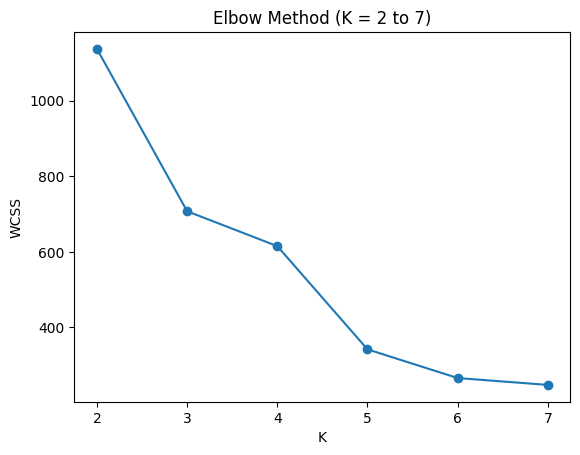

In [ ]:
wcss = []
K_range = range(2, 8)  # من 2 إلى 7

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_clustering)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method (K = 2 to 7)")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()


## 4)Calculate Silhouette Score foe each k and Evaluation
We calculated the Silhouette Score for each value of K (from 2 to 7).
The Silhouette Score measures how well-separated and cohesive the clusters are.
Higher scores indicate better clustering quality.



In [ ]:
silhouette_scores = []

for k in K_range:  # نفس K_range = range(2, 7)
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_clustering)
    sil = silhouette_score(df_clustering, labels)
    silhouette_scores.append([k, sil])
    print(f"K = {k}, Silhouette = {sil:.4f}")


K = 2, Silhouette = 0.6147
K = 3, Silhouette = 0.5188
K = 4, Silhouette = 0.4541
K = 5, Silhouette = 0.5256
K = 6, Silhouette = 0.5412
K = 7, Silhouette = 0.5196


## 5)Final K Selection
Based on the Silhouette Score, K = 2 produced the best clustering performance with the highest score of 0.6147.
However, as required in the project, additional clustering configurations (K = 5 and K = 7) were also analyzed to provide a full comparison.

In [ ]:
k_list = [2, 5, 7]

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df[f"Cluster_{k}"] = kmeans.fit_predict(df_clustering)

    sil = silhouette_score(df_clustering, df[f"Cluster_{k}"])
    print(f"\nK = {k} → Silhouette = {sil:.4f}")
    print(df[f"Cluster_{k}"].value_counts())



K = 2 → Silhouette = 0.6147
Cluster_2
0    532
1    392
Name: count, dtype: int64

K = 5 → Silhouette = 0.5256
Cluster_5
1    256
4    236
2    186
0    178
3     68
Name: count, dtype: int64

K = 7 → Silhouette = 0.5196
Cluster_7
4    236
0    178
5    136
2    118
1    114
6     74
3     68
Name: count, dtype: int64


In [ ]:
df = pd.read_csv("Preprocessed_dataset.csv")

# نحذف فقط الكلاس
df_clustering = df.drop(columns=["Dominant_Emotion"])


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(df_clustering)
df["Cluster_2"] = clusters


## 6)1.Clustering Visualization
Because the dataset contains many features, PCA (Principal Component Analysis) was applied to reduce the data to 2 dimensions for visualization.
PCA allows us to visually distinguish clusters more clearly.

In [ ]:
from sklearn.cluster import KMeans

X = df.drop(columns=["Dominant_Emotion"])

for k in [2,5,7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df[f"Cluster_{k}"] = kmeans.fit_predict(X)


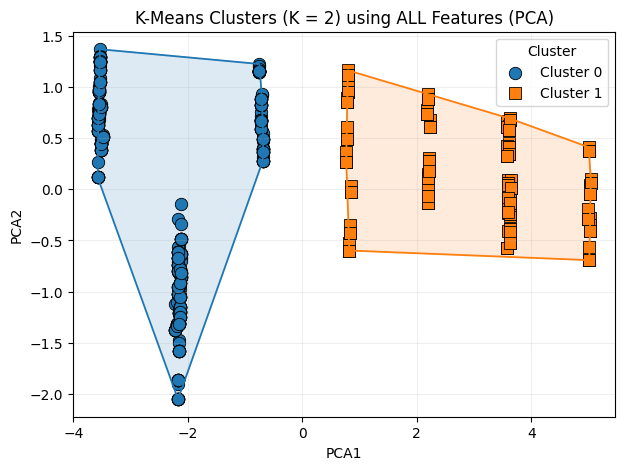

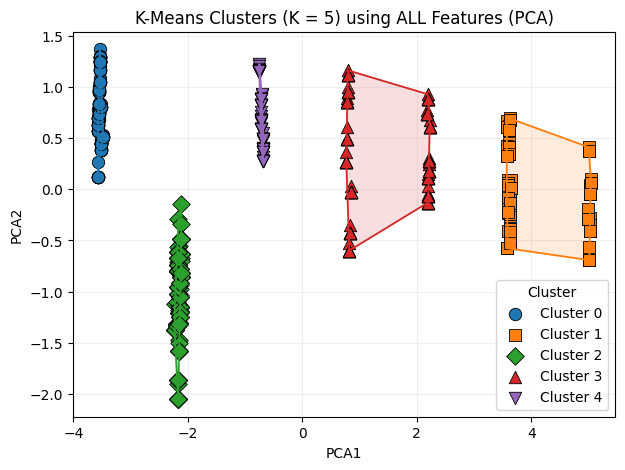

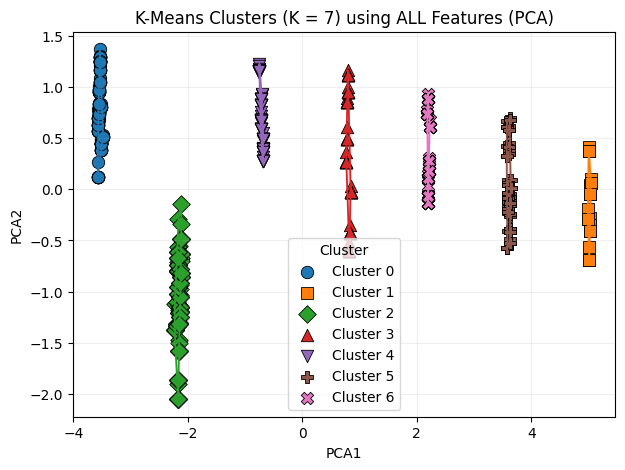

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull   # مهم

k_values = [2, 5, 7]
markers = {0:"o", 1:"s", 2:"D", 3:"^", 4:"v", 5:"P", 6:"X"}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

for k in k_values:
    plt.figure(figsize=(7,5))
    labels = df[f"Cluster_{k}"]

    for cid in sorted(labels.unique()):
        subset = df[labels == cid]
        points = subset[["PCA1", "PCA2"]].values

        # لو الكلستر فيه أقل من 3 نقاط ما نقدر نسوي له مضلع
        if len(points) >= 3:
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]

            # تعبئة المنطقة بلون خفيف
            plt.fill(
                hull_points[:,0],
                hull_points[:,1],
                color=colors[cid % len(colors)],
                alpha=0.15
            )

            # رسم حدود المضلع
            plt.plot(
                np.append(hull_points[:,0], hull_points[0,0]),
                np.append(hull_points[:,1], hull_points[0,1]),
                color=colors[cid % len(colors)],
                linewidth=1.3
            )

        # نقاط الكلستر نفسها
        plt.scatter(
            subset["PCA1"],
            subset["PCA2"],
            s=80,
            color=colors[cid % len(colors)],
            marker=markers.get(cid, "o"),
            edgecolors="black",
            linewidth=0.6,
            label=f"Cluster {cid}"
        )

    plt.title(f"K-Means Clusters (K = {k}) using ALL Features (PCA)")
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Cluster")
    plt.grid(alpha=0.2)
    plt.show()


### 2.Optimal K Selection Based on Visualization
Based on the PCA visualizations, K = 2 is the best choice because the two clusters are clearly separated with no overlap, and each cluster is compact and cohesive.
In contrast, K = 5 splits one natural group into smaller parts, and K = 7 produces fragmented and overlapping clusters.
Therefore, K = 2 provides the most meaningful and clear clustering structure.

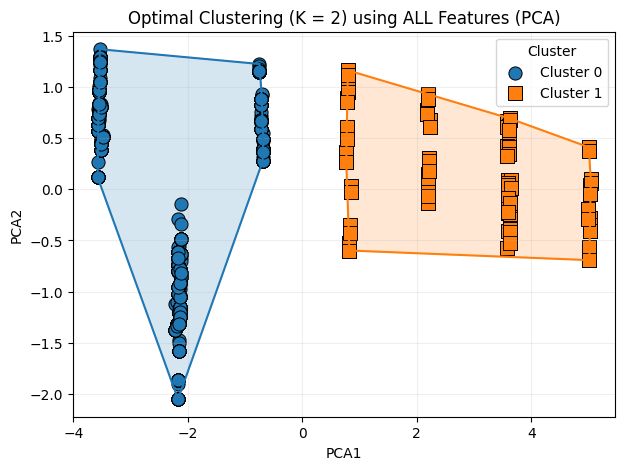

In [ ]:
optimal_k = 2
plt.figure(figsize=(7,5))
labels = df[f"Cluster_{optimal_k}"]

for cid in sorted(labels.unique()):
    subset = df[labels == cid]
    points = subset[["PCA1", "PCA2"]].values

    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]

        plt.fill(
            hull_points[:,0],
            hull_points[:,1],
            color=colors[cid % len(colors)],
            alpha=0.18
        )
        plt.plot(
            np.append(hull_points[:,0], hull_points[0,0]),
            np.append(hull_points[:,1], hull_points[0,1]),
            color=colors[cid % len(colors)],
            linewidth=1.5
        )

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=90,
        color=colors[cid % len(colors)],
        marker=markers.get(cid, "o"),
        edgecolors="black",
        linewidth=0.7,
        label=f"Cluster {cid}"
    )

plt.title(f"Optimal Clustering (K = {optimal_k}) using ALL Features (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.show()


## Clustering Evaluation: Silhouette Score and WCSS Comparison
To evaluate the quality of the clustering performance

· The silhouette score helped us determine how well-separated and cohesive our clusters were, with K=2 achieving the highest score of 0.7183, indicating clear and well-defined clusters.                                                                                
· The Elbow Method was used to identify the optimal number of clusters by plotting WCSS values for K ranging from 2 to 7. Although no sharp elbow was observed, the method confirmed that increasing K beyond 2 did not significantly improve cluster compactness.                                                                                                     
· K-means performed effectively on our social media usage dataset, with K=2 yielding the best results according to both silhouette score and WCSS metrics.                                                 
· However, cluster interpretation also depends on the nature of our dataset, as behavioral data related to social media usage may not form perfectly separated clusters due to gradual variations in user behavior patterns


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 5, 7]   # القيم اللي اشتغلنا عليها

cluster_results = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)     # X = كل الأعمدة بدون Dominant_Emotion
    sil = silhouette_score(X, labels)
    wcss = kmeans.inertia_

    cluster_results[k] = {
        "silhouette": sil,
        "wcss": wcss
    }
print("Comparison of K values:\n")
for k in cluster_results.keys():
    print(f"K = {k}")
    print(f"  Silhouette Score: {cluster_results[k]['silhouette']:.4f}")
    print(f"  WCSS: {cluster_results[k]['wcss']:.2f}")
    print("-" * 30)


Comparison of K values:

K = 2
  Silhouette Score: 0.6522
  WCSS: 3008.70
------------------------------
K = 5
  Silhouette Score: 0.6513
  WCSS: 617.22
------------------------------
K = 7
  Silhouette Score: 0.6637
  WCSS: 360.73
------------------------------


### Cluster Interpretation for K = 2 (Aligned with Project Goal)
In this section, we analyze the two clusters generated using K = 2 to understand how users differ in their social media engagement levels.
The goal is to identify whether these behavioral differences relate to emotional well-being, which directly supports the project objective.
The interpretation is based on the average values of all features and the most significant differences between the two clusters.

In [ ]:
df["Cluster_2"] = KMeans(n_clusters=2, random_state=42).fit_predict(X)


In [ ]:
# ====== Cluster Interpretation for K = 2 (Linked to Project Goal) ======

df_comp = X.copy()  # X = all features without Dominant_Emotion
df_comp["Cluster"] = df["Cluster_2"]

cluster_profile = df_comp.groupby("Cluster").mean()
difference = (cluster_profile.loc[0] - cluster_profile.loc[1]).abs()

print("=== Cluster Profiles (Averages for Each Feature) ===\n")
print(cluster_profile)

print("\n=== Differences Between Clusters (Sorted) ===\n")
print(difference.sort_values(ascending=False))


# ======================
#  AUTO-GENERATED INTERPRETATION (English)
# ======================

print("\n\n================ CLUSTER INTERPRETATION (Connected to Project Goal) ================\n")

# Determine which cluster is higher in engagement
high_cluster = 0 if cluster_profile.loc[0].mean() > cluster_profile.loc[1].mean() else 1
low_cluster = 1 - high_cluster

print(f"Cluster {high_cluster} shows generally higher averages across most engagement features.\n")
print(f"Cluster {low_cluster} shows generally lower averages across most engagement features.\n")

print("Key features with the largest differences between the clusters:")
for feature, value in difference.sort_values(ascending=False).head(4).items():
    print(f"- {feature}: difference = {value:.4f}")

print("\n================ INTERPRETATION BASED ON PROJECT GOAL ================\n")

print(
f"Cluster {high_cluster} represents **High Social Media Engagement Users**, who spend more time online, send more messages, make more posts, "
"and receive more interactions. According to the project's goal—exploring the relationship between social media engagement and emotional well-being—"
"this group may be more exposed to emotional fluctuations such as anxiety, stress, or dependency due to their intensive usage patterns.\n"
)

print(
f"Cluster {low_cluster} represents **Low-to-Moderate Engagement Users**, who show more balanced and healthier usage behavior. "
"Based on emotional well-being literature, individuals with moderate social media use tend to experience more stable emotional states.\n"
)

print(
"These findings support the project’s main objective by showing that differences in engagement levels naturally separate users into two behavioral groups, "
"which may correlate with their emotional well-being patterns. Higher engagement may signal potential emotional risks, while moderate engagement is linked "
"to better emotional balance.\n"
)

print("================ END OF ANALYSIS ================")


=== Cluster Profiles (Averages for Each Feature) ===

              Age    Gender  Platform  Daily_Usage_Time (minutes)  \
Cluster                                                             
0        0.483888  0.471805  0.887218                    0.404370   
1        0.437682  0.415816  4.653061                    0.280772   

         Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
Cluster                                                                     
0             0.360902                0.379860                   0.371092   
1             0.301385                0.275729                   0.347811   

         Messages_Sent_Per_Day  Cluster_2      PCA1      PCA2  
Cluster                                                        
0                     0.363946        0.0 -2.299276 -0.057807  
1                     0.325194        1.0  3.120447  0.078452  

=== Differences Between Clusters (Sorted) ===

PCA1                          5.419723
Platform         

In [ ]:
from sklearn.decomposition import PCA

# نحدد الأعمدة الرقمية فقط (كل الأعمدة ما عدا الكلاس)
features = df.drop(columns=["Dominant_Emotion"])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]
